### Model

### Data Preprocess

In [1]:
import pandas as pd
train_df = pd.read_csv('data/train_annotated.csv')
test_df = pd.read_csv('data/test_annotated.csv')
train_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11191691,38842535,"['Introduction', 'Results and Discussion', 'Co...","['background', 'conclusions', 'conclusions', '..."
1,PMC11182025,38887617,"['Introduction', 'Materials & Methods', 'Resul...","['background', 'methods', 'results', 'conclusi..."
2,PMC10511328,37704722,"['Main', 'Pooled longitudinal analyses', 'Popu...","['background', 'results', 'results', 'results'..."
3,PMC10632145,37914938,"['Main', 'Population imaging and single-cell a...","['background', 'results', 'results', 'results'..."
4,PMC1084334,15884974,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."
...,...,...,...,...
635,PMC11187391,38123960,['Ethics statements'],[nan]
636,PMC11187998,38903349,"['Introduction', 'Case presentation', 'Discuss...","['background', 'methods', 'conclusions', 'conc..."
637,PMC11191920,38905421,"['1. Introduction', '2. Patients and methods',...","['background', 'methods', 'results', 'conclusi..."
638,PMC10978839,38548747,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."


In [2]:
test_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11184573,38888203,"['INTRODUCTION', 'MATERIALS AND METHODS', 'DIS...","['background', 'methods', 'conclusions', 'conc..."
1,PMC11183239,38886373,"['Introduction', 'Subjects and methods', 'Resu...","['background', 'methods', 'results', 'conclusi..."
2,PMC11187291,38903966,"['Introduction', 'Methods', 'Results', 'Discus...","['background', 'methods', 'results', 'conclusi..."
3,PMC11177991,38883749,"['INTRODUCTION', 'MATERIALS AND METHODS', 'RES...","['background', 'methods', 'results', 'conclusi..."
4,PMC11187304,38903638,"['Introduction', 'Methods', 'Case reports', 'D...","['background', 'methods', 'methods', 'conclusi..."
...,...,...,...,...
155,PMC11181322,38771959,"['Introduction', 'Results and Discussion', 'Co...","['background', 'conclusions', 'conclusions', '..."
156,PMC11186409,38899065,"['Introduction', 'Materials and methods', 'Res...","['background', 'methods', 'results', 'conclusi..."
157,PMC11185683,38895272,"['Introduction', 'Results', 'Discussion', 'Mat...","['background', 'results', 'conclusions', 'meth..."
158,PMC11161898,38854388,"['METHODS', 'RESULTS', 'DISCUSSION', 'Notes']","['methods', 'results', 'conclusions', 'backgro..."


In [3]:
import ast
import numpy as np

# import numpy as np

def eval_with_nan(x):
    if isinstance(x, list):
        return [np.nan if (isinstance(i, float) and np.isnan(i)) else i for i in x]
    try:
        # 這邊直接 eval 而且給定 locals
        val = eval(x, {"nan": np.nan, "NaN": np.nan, "np": np})
        if isinstance(val, list):
            return [np.nan if (isinstance(i, float) and np.isnan(i)) else i for i in val]
        else:
            return val
    except Exception:
        return x  # 如果 eval 還失敗就原樣保留

# 用在你的 dataframe 上
# df_j['sec-norm'] = df_j['sec-norm'].apply(eval_with_nan)




In [4]:

train_df['sec-title'] = train_df['sec-title'].apply(ast.literal_eval)
test_df['sec-title'] = test_df['sec-title'].apply(ast.literal_eval)
train_df['sec-norm'] = train_df['sec-norm'].apply(eval_with_nan)
test_df['sec-norm'] = test_df['sec-norm'].apply(eval_with_nan)

In [5]:
train_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11191691,38842535,"[Introduction, Results and Discussion, Conclus...","[background, conclusions, conclusions, backgro..."
1,PMC11182025,38887617,"[Introduction, Materials & Methods, Results, D...","[background, methods, results, conclusions, co..."
2,PMC10511328,37704722,"[Main, Pooled longitudinal analyses, Populatio...","[background, results, results, results, result..."
3,PMC10632145,37914938,"[Main, Population imaging and single-cell acti...","[background, results, results, results, result..."
4,PMC1084334,15884974,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."
...,...,...,...,...
635,PMC11187391,38123960,[Ethics statements],[nan]
636,PMC11187998,38903349,"[Introduction, Case presentation, Discussion, ...","[background, methods, conclusions, conclusions]"
637,PMC11191920,38905421,"[1. Introduction, 2. Patients and methods, 3. ...","[background, methods, results, conclusions, ba..."
638,PMC10978839,38548747,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods, ba..."


In [6]:
test_df

,PMCID,PMID,sec-title,sec-norm
0,PMC11184573,38888203,"[INTRODUCTION, MATERIALS AND METHODS, DISCUSSI...","[background, methods, conclusions, conclusions..."
1,PMC11183239,38886373,"[Introduction, Subjects and methods, Results, ...","[background, methods, results, conclusions, co..."
2,PMC11187291,38903966,"[Introduction, Methods, Results, Discussion, C...","[background, methods, results, conclusions, co..."
3,PMC11177991,38883749,"[INTRODUCTION, MATERIALS AND METHODS, RESULTS,...","[background, methods, results, conclusions, co..."
4,PMC11187304,38903638,"[Introduction, Methods, Case reports, Discussi...","[background, methods, methods, conclusions, co..."
...,...,...,...,...
155,PMC11181322,38771959,"[Introduction, Results and Discussion, Conclus...","[background, conclusions, conclusions, methods..."
156,PMC11186409,38899065,"[Introduction, Materials and methods, Results,...","[background, methods, results, conclusions, ba..."
157,PMC11185683,38895272,"[Introduction, Results, Discussion, Materials ...","[background, results, conclusions, methods]"
158,PMC11161898,38854388,"[METHODS, RESULTS, DISCUSSION, Notes]","[methods, results, conclusions, background]"


In [7]:
import pandas as pd

def convert_to_sep_format(row):
    titles = row["sec-title"]  # 取得標題列表
    labels = row["sec-norm"]   # 取得標籤列表

    inputs_with_sep = []
    labels_with_sep = []

    for i, title in enumerate(titles):
        inputs_with_sep.append(title)
        labels_with_sep.append("O")  # 一般 token 標記為 "O"
        
        # 在每個標題後面插入 [SEP]，對應標籤來自 sec-norm
        if i < len(labels):  # 確保標籤數量正確
            inputs_with_sep.append("[SEP]")
            if pd.isna(labels[i]):
                labels_with_sep.append('-100') ## none labeled
            else:
                labels_with_sep.append(labels[i])  # 讓 [SEP] 位置承擔標籤

    return pd.Series([inputs_with_sep, labels_with_sep])


# 對 DataFrame 進行轉換
train_df[["inputs_with_sep", "labels_with_sep"]] = train_df.apply(convert_to_sep_format, axis=1)
train_df = train_df[
    train_df['labels_with_sep'].apply(len) - train_df['labels_with_sep'].apply(lambda x: x.count('O')) > 0
]

test_df[["inputs_with_sep", "labels_with_sep"]] = test_df.apply(convert_to_sep_format, axis=1)
test_df = test_df[
    test_df['labels_with_sep'].apply(len) - test_df['labels_with_sep'].apply(lambda x: x.count('O')) > 0
]

In [8]:
train_df = train_df.drop(columns=['sec-title', 'sec-norm'])
train_df

,PMCID,PMID,inputs_with_sep,labels_with_sep
0,PMC11191691,38842535,"[Introduction, [SEP], Results and Discussion, ...","[O, background, O, conclusions, O, conclusions..."
1,PMC11182025,38887617,"[Introduction, [SEP], Materials & Methods, [SE...","[O, background, O, methods, O, results, O, con..."
2,PMC10511328,37704722,"[Main, [SEP], Pooled longitudinal analyses, [S...","[O, background, O, results, O, results, O, res..."
3,PMC10632145,37914938,"[Main, [SEP], Population imaging and single-ce...","[O, background, O, results, O, results, O, res..."
4,PMC1084334,15884974,"[Introduction, [SEP], Results, [SEP], Discussi...","[O, background, O, results, O, conclusions, O,..."
...,...,...,...,...
635,PMC11187391,38123960,"[Ethics statements, [SEP]]","[O, -100]"
636,PMC11187998,38903349,"[Introduction, [SEP], Case presentation, [SEP]...","[O, background, O, methods, O, conclusions, O,..."
637,PMC11191920,38905421,"[1. Introduction, [SEP], 2. Patients and metho...","[O, background, O, methods, O, results, O, con..."
638,PMC10978839,38548747,"[Introduction, [SEP], Results, [SEP], Discussi...","[O, background, O, results, O, conclusions, O,..."


In [9]:
from sklearn.model_selection import train_test_split

# 將 train_df 拆成 87.5% 訓練資料 和 12.5% 驗證資料
train_df, val_df = train_test_split(train_df, test_size=1/8, random_state=42, shuffle=True)

train_df

,PMCID,PMID,inputs_with_sep,labels_with_sep
304,PMC11189173,38900748,"[Introduction, [SEP], Methods, [SEP], Result, ...","[O, background, O, methods, O, results, O, con..."
414,PMC11180756,38887229,"[Introduction, [SEP], Materials and methods, [...","[O, background, O, methods, O, results, O, con..."
577,PMC11073751,38716403,"[Background, [SEP], Methods, [SEP], Results, [...","[O, background, O, methods, O, results, O, con..."
259,PMC10962890,38131617,"[INTRODUCTION, [SEP], METHODS, [SEP], RESULTS,...","[O, background, O, methods, O, results, O, con..."
594,PMC11152445,38896724,"[INTRODUCTION, [SEP], OUTCOMES AFTER INTENSIVE...","[O, background, O, -100, O, -100, O, -100, O, ..."
...,...,...,...,...
71,PMC11192717,38906906,"[Introduction, [SEP], Results, [SEP], Discussi...","[O, background, O, results, O, conclusions, O,..."
106,PMC11192365,38857285,"[Introduction, [SEP], Results, [SEP], Discussi...","[O, background, O, results, O, conclusions, O,..."
270,PMC11186357,38904030,"[Introduction, [SEP], Materials and Methods, [...","[O, background, O, methods, O, results, O, con..."
435,PMC11189877,38900377,"[Background, [SEP], Case presentation, [SEP], ...","[O, background, O, methods, O, conclusions, O,..."


In [10]:
val_df

,PMCID,PMID,inputs_with_sep,labels_with_sep
570,PMC11186153,38898433,"[Introduction, [SEP], Materials and methods, [...","[O, background, O, methods, O, results, O, con..."
265,PMC11184630,38894760,"[Introduction, [SEP], Case presentation, [SEP]...","[O, background, O, methods, O, conclusions, O,..."
291,PMC1065320,15743470,"[Introduction, [SEP], Materials and methods, [...","[O, background, O, methods, O, results, O, con..."
597,PMC11180906,38887537,"[Introduction, [SEP], Materials and methods, [...","[O, background, O, methods, O, results, O, con..."
174,PMC11184868,38886767,"[Background, [SEP], Stem-cell derived ECs, [SE...","[O, background, O, -100, O, -100, O, -100, O, ..."
...,...,...,...,...
527,PMC11190884,38842026,"[Introduction, [SEP], Nucleic Acid, [SEP], Bio...","[O, background, O, results, O, results, O, res..."
86,PMC11188041,36347335,"[Introduction, [SEP], Materials and methods, [...","[O, background, O, methods, O, results, O, con..."
369,PMC11186168,38890641,"[Introduction, [SEP], Methods, [SEP], Results,...","[O, background, O, methods, O, results, O, con..."
636,PMC11187998,38903349,"[Introduction, [SEP], Case presentation, [SEP]...","[O, background, O, methods, O, conclusions, O,..."


### model

In [11]:
from torch.utils.data import DataLoader
from transformers import BertTokenizerFast

from transformers import AutoTokenizer, AutoModel



tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")

MAX_LENGTH = 64  # 你希望的最大序列長度

def collate_fn(batch):
    input_ids, attention_masks, labels, word_lists, word_id_lists = zip(*batch)
    return (
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.stack(labels),
        list(word_lists),
        list(word_id_lists)  # list of lists，不要 stack
    )



In [13]:
import torch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

# 載入 BERT Tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 建立標籤映射表

label2id = {"O": 0, "objective": 1, "background": 2, "methods": 3, "results": 4, "conclusions": 5}
# label2id = defaultdict(int, label2id)
id2label = {v: k for k, v in label2id.items()}

class SectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        inputs_with_sep = ['[CLS]'] + row["inputs_with_sep"]  # 原始詞列表
        label_with_sep = [0] + row["labels_with_sep"]

        # Tokenize
        encoded = self.tokenizer(
            inputs_with_sep,
            is_split_into_words=True,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)

        # 根據 word_ids 展開 label 給每個 token
        word_ids = encoded.word_ids(batch_index=0)
        labels_per_token = []

        for word_idx in word_ids:
            if word_idx is None:
                labels_per_token.append(0)  # special tokens
            else:
                label_name = label_with_sep[word_idx]
                label_id = label2id.get(label_name, 0)  # fallback 用 "O"
                labels_per_token.append(label_id)

        labels = torch.tensor(labels_per_token, dtype=torch.long)

        return input_ids, attention_mask, labels, inputs_with_sep, word_ids


from sklearn.model_selection import train_test_split

train_dataset = SectionDataset(train_df, tokenizer, 64)
val_dataset = SectionDataset(val_df, tokenizer, 64)
test_dataset = SectionDataset(test_df, tokenizer, 64)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)



In [14]:
token_lens = []

for i in range(len(train_dataset)):
    input_ids, attention_mask, labels, _, _ = train_dataset[i]
    true_len = attention_mask.sum().item()  # 不包含 padding 的 token 數
    token_lens.append(true_len)

import numpy as np
print(f"🔍 Token length stats (train set):")
print(f"  Max: {max(token_lens)}")
print(f"  Mean: {np.mean(token_lens):.2f}")
print(f"  95th percentile: {np.percentile(token_lens, 95):.2f}")


🔍 Token length stats (train set):
  Max: 64
  Mean: 23.41
  95th percentile: 47.05


In [15]:
token_lens = []

for i in range(len(test_dataset)):
    input_ids, attention_mask, labels, _, _ = test_dataset[i]
    true_len = attention_mask.sum().item()  # 不包含 padding 的 token 數
    token_lens.append(true_len)

import numpy as np
print(f"🔍 Token length stats (test set):")
print(f"  Max: {max(token_lens)}")
print(f"  Mean: {np.mean(token_lens):.2f}")
print(f"  95th percentile: {np.percentile(token_lens, 95):.2f}")


🔍 Token length stats (test set):
  Max: 64
  Mean: 23.48
  95th percentile: 54.00


In [34]:
# !pip uninstall TorchCRF
# !pip install transformers==4.30.2


In [16]:
import torch.nn as nn
from transformers import BertModel
from torchcrf import CRF

class BERT_CRF(nn.Module):
    def __init__(self, num_labels):
        super(BERT_CRF, self).__init__()
        self.bert = AutoModel.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
        self.hidden_dim = self.bert.config.hidden_size
        self.fc = nn.Linear(self.hidden_dim, num_labels)  # 轉換為標籤 logits
        self.crf = CRF(num_labels, batch_first=True)  # CRF 層

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        emissions = self.fc(sequence_output)  # (batch_size, seq_len, num_labels)

        if labels is not None:
            loss = -self.crf(emissions, labels, mask=attention_mask.byte(), reduction="mean")
            return loss
        else:
            predictions = self.crf.decode(emissions, mask=attention_mask.byte())
            return predictions


Epoch 1: 100%|██████████| 56/56 [00:05<00:00, 10.48it/s]


Epoch 1/100 | Train Loss: 743.4131 | Val Loss: 90.3966


Epoch 2: 100%|██████████| 56/56 [00:05<00:00, 10.52it/s]


Epoch 2/100 | Train Loss: 626.8912 | Val Loss: 89.7239


Epoch 3: 100%|██████████| 56/56 [00:05<00:00, 10.53it/s]


...

Epoch 98/100 | Train Loss: 17.3268 | Val Loss: 18.8747


Epoch 99: 100%|██████████| 56/56 [00:05<00:00, 10.67it/s]


Epoch 99/100 | Train Loss: 5.5246 | Val Loss: 17.3003


Epoch 100: 100%|██████████| 56/56 [00:05<00:00, 10.67it/s]


Epoch 100/100 | Train Loss: 18.7853 | Val Loss: 16.4991


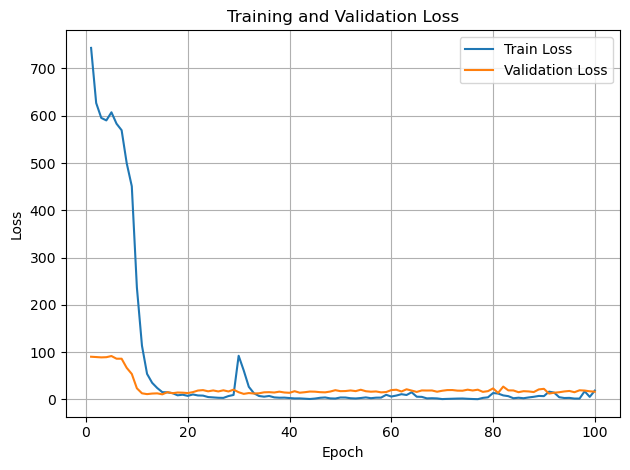

In [53]:
import torch.optim as optim
from tqdm import tqdm

import matplotlib.pyplot as plt

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERT_CRF(num_labels=len(label2id)).to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # === Validation ===
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
            val_loss = model(input_ids, attention_mask, labels)
            total_val_loss += val_loss.item()

    train_losses.append(total_loss)
    val_losses.append(total_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {total_loss:.4f} | Val Loss: {total_val_loss:.4f}")

plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import precision_recall_fscore_support
# 載入預訓練參數
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERT_CRF(num_labels=len(label2id)).to(device)
state_dict = torch.load("models/bert_crf_pubMed_pretrained_300seed_max64.pth")
# 允許部分 miss（例如你有改一些架構）
model.load_state_dict(state_dict, strict=False)
model = model.to(device)

model.eval()
all_true_labels = []
all_pred_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
        word_lists, word_id_lists = batch[3], batch[4]
        # sep_none_type = [x.to(device) for x in batch[5]]
        predictions = model(input_ids, attention_mask)

        for i in range(len(word_lists)):
            word_list = word_lists[i]          # 原始詞 list
            word_ids = word_id_lists[i]        # token 對應的 word index
            preds = predictions[i]
            trues = labels[i]
            tokens = input_ids[i]

            for idx, word_idx in enumerate(word_ids):
                if word_idx is None:
                    continue
                word = word_list[word_idx]
                if word == "[SEP]" and trues[idx].item() != -1:
                    all_true_labels.append(id2label[trues[idx].item()])
                    all_pred_labels.append(id2label[preds[idx]])

print(f"True Labels: {len(all_true_labels)}, Pred Labels: {len(all_pred_labels)}")
print(f"Unique True Labels: {set(all_true_labels)}")
print(f"Unique Pred Labels: {set(all_pred_labels)}")

precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="macro"
)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")


/jet/home/slin23/.local/lib/python3.12/site-packages/torchcrf/__init__.py:305: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:529.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)


True Labels: 1022, Pred Labels: 1022
Unique True Labels: {'conclusions', 'objective', 'background', 'O', 'methods', 'results'}
Unique Pred Labels: {'conclusions', 'background', 'O', 'methods', 'results'}
Test Precision: 0.7253
Test Recall: 0.7218
Test F1 Score: 0.7234


/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from sklearn.metrics import accuracy_score
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="weighted"
)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print(f"Test Accuracy: {accuracy_score(all_true_labels, all_pred_labels)}")

Test Precision: 0.9428
Test Recall: 0.9452
Test F1 Score: 0.9439
Test Accuracy: 0.9452054794520548


/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
from sklearn.metrics import classification_report

print(classification_report(all_true_labels, all_pred_labels, digits=4))


              precision    recall  f1-score   support

           O     0.5769    0.5556    0.5660        27
  background     0.9665    0.9726    0.9696       475
 conclusions     0.9827    0.9913    0.9870       229
     methods     0.9145    0.9392    0.9267       148
   objective     0.0000    0.0000    0.0000         2
     results     0.9111    0.8723    0.8913       141

    accuracy                         0.9452      1022
   macro avg     0.7253    0.7218    0.7234      1022
weighted avg     0.9428    0.9452    0.9439      1022



/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/packages/anaconda3-2024.10-1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [20]:
from sklearn.metrics import accuracy_score
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true_labels, all_pred_labels, average="micro"
)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print(f"Test Accuracy: {accuracy_score(all_true_labels, all_pred_labels)}")

Test Precision: 0.9452
Test Recall: 0.9452
Test F1 Score: 0.9452
Test Accuracy: 0.9452054794520548


In [58]:
torch.save(model.state_dict(), "models/bert_crf_pubMed_pretrained_300seed_max64.pth")

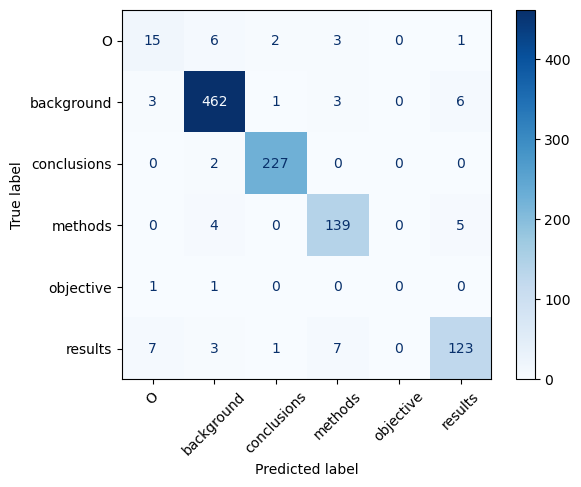

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = sorted(set(all_true_labels) | set(all_pred_labels))  # 統一所有可能的 label

cm = confusion_matrix(all_true_labels, all_pred_labels, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues")

### Annotated

In [7]:
import pandas as pd
test_df = pd.read_csv('Processed_Headings/train_df.csv')
test_df

,PMCID,PMID,inputs_with_sep,labels_with_sep
0,PMC6254157,19384281,"['1. Introduction', '[SEP]', '2. Results and D...","['O', '-100', 'O', '-100', 'O', '-100', 'O', '..."
1,PMC4032680,24955383,"['1. Introduction', '[SEP]', '2. Model Hypothe...","['O', '-100', 'O', '-100', 'O', '-100', 'O', '..."
2,PMC6723279,31349708,"['1. Introduction', '[SEP]', '2. Materials and...","['O', '-100', 'O', '-100', 'O', '-100', 'O', '..."
3,PMC5290626,28159004,"['Introduction', '[SEP]', 'Large scale visuali...","['O', 'background', 'O', '-100', 'O', '-100', ..."
4,PMC4172818,25193322,"['Background', '[SEP]', 'Methods', '[SEP]', 'R...","['O', 'background', 'O', 'methods', 'O', 'resu..."
...,...,...,...,...
1922647,PMC3786481,24155782,"['Introduction', '[SEP]', 'Conclusions', '[SEP]']","['O', 'background', 'O', 'conclusions']"
1922648,PMC7926844,33671592,"['1. Introduction', '[SEP]', '2. Materials and...","['O', '-100', 'O', '-100', 'O', '-100', 'O', '..."
1922649,PMC11190545,0,"['Introduction', '[SEP]', 'Dataset description...","['O', 'background', 'O', '-100', 'O', 'methods..."
1922650,PMC3952259,0,"['Introduction', '[SEP]', 'Objectives', '[SEP]...","['O', 'background', 'O', 'objective', 'O', 'me..."


In [8]:
import ast
test_df['inputs_with_sep'] = test_df['inputs_with_sep'].apply(ast.literal_eval)
test_df['labels_with_sep'] = test_df['labels_with_sep'].apply(ast.literal_eval)

In [9]:
test_df

,PMCID,PMID,inputs_with_sep,labels_with_sep
0,PMC6254157,19384281,"[1. Introduction, [SEP], 2. Results and Discus...","[O, -100, O, -100, O, -100, O, -100]"
1,PMC4032680,24955383,"[1. Introduction, [SEP], 2. Model Hypotheses, ...","[O, -100, O, -100, O, -100, O, -100, O, -100, ..."
2,PMC6723279,31349708,"[1. Introduction, [SEP], 2. Materials and Meth...","[O, -100, O, -100, O, -100, O, -100, O, -100]"
3,PMC5290626,28159004,"[Introduction, [SEP], Large scale visualizatio...","[O, background, O, -100, O, -100, O, -100, O, ..."
4,PMC4172818,25193322,"[Background, [SEP], Methods, [SEP], Results, [...","[O, background, O, methods, O, results, O, con..."
...,...,...,...,...
1922647,PMC3786481,24155782,"[Introduction, [SEP], Conclusions, [SEP]]","[O, background, O, conclusions]"
1922648,PMC7926844,33671592,"[1. Introduction, [SEP], 2. Materials and Meth...","[O, -100, O, -100, O, -100, O, -100, O, -100]"
1922649,PMC11190545,0,"[Introduction, [SEP], Dataset description, [SE...","[O, background, O, -100, O, methods, O, -100, ..."
1922650,PMC3952259,0,"[Introduction, [SEP], Objectives, [SEP], Metho...","[O, background, O, objective, O, methods, O, r..."


In [11]:
from torch.utils.data import DataLoader
from transformers import BertTokenizerFast

from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")

MAX_LENGTH = 512  # 你希望的最大序列長度

def collate_fn(batch):
    input_ids, attention_masks, labels, word_lists, word_id_lists, original_title = zip(*batch)
    return (
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.stack(labels),
        list(word_lists),
        list(word_id_lists),  # list of lists，不要 stack
        list(original_title)
    )



In [12]:
import torch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

# 載入 BERT Tokenizer
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 建立標籤映射表

label2id = {"O": 0, "objective": 1, "background": 2, "methods": 3, "results": 4, "conclusions": 5}
# label2id = defaultdict(int, label2id)
id2label = {v: k for k, v in label2id.items()}

class SectionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=MAX_LENGTH):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        inputs_with_sep = ['[CLS]'] + row["inputs_with_sep"]  # 原始詞列表
        label_with_sep = [0] + row["labels_with_sep"]

        # Tokenize
        encoded = self.tokenizer(
            inputs_with_sep,
            is_split_into_words=True,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)

        # 根據 word_ids 展開 label 給每個 token
        word_ids = encoded.word_ids(batch_index=0)
        labels_per_token = []

        for word_idx in word_ids:
            if word_idx is None:
                labels_per_token.append(0)  # special tokens
            else:
                label_name = label_with_sep[word_idx]
                label_id = label2id.get(label_name, 0)  # fallback 用 "O"
                labels_per_token.append(label_id)

        labels = torch.tensor(labels_per_token, dtype=torch.long)

        return input_ids, attention_mask, labels, inputs_with_sep, word_ids, [item for item in row["inputs_with_sep"] if item != '[SEP]']


from sklearn.model_selection import train_test_split


test_dataset = SectionDataset(test_df, tokenizer)

test_loader = DataLoader(test_dataset, batch_size=10, collate_fn=collate_fn)



In [19]:
from sklearn.metrics import precision_recall_fscore_support
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERT_CRF(num_labels=6)
# 載入預訓練參數
state_dict = torch.load("models/bert_crf_pubMed_pretrained_300seed_max64.pth")
# 允許部分 miss（例如你有改一些架構）
model.load_state_dict(state_dict, strict=False)
model = model.to(device)

model.eval()
sec_title = []
sec_norm = []


with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids, attention_mask, labels = [x.to(device) for x in batch[:3]]
        word_lists, word_id_lists = batch[3], batch[4]
        predictions = model(input_ids, attention_mask)
        original_texts = batch[5]

        
        for i in range(len(word_lists)):
            word_list = word_lists[i]          # 原始詞 list
            word_ids = word_id_lists[i]        # token 對應的 word index
            preds = predictions[i]
            trues = labels[i]
            tokens = input_ids[i]
            original_text = original_texts[i]

            to_append_norm = []
            for idx, word_idx in enumerate(word_ids):
                if word_idx is None:
                    continue
                word = word_list[word_idx]
                if word == "[SEP]" and trues[idx].item() != -1:
                    to_append_norm.append(id2label[preds[idx]])

            if len(original_text) > len(to_append_norm):
                original_text = original_text[:len(to_append_norm)]
                
            if len(original_text) != len(to_append_norm):
                print(False)
                    
            sec_title.append(original_text)
            sec_norm.append(to_append_norm)


  0%|          | 0/192266 [00:00<?, ?it/s]/jet/home/slin23/.local/lib/python3.12/site-packages/torchcrf/__init__.py:305: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:529.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
100%|██████████| 192266/192266 [6:47:45<00:00,  7.86it/s]   


In [20]:
pd.DataFrame({'sec_title': sec_title, 'sec_norm': sec_norm}).to_csv('annotated.csv')